In [11]:
import numpy as np
import matplotlib.pyplot as plt


# This is only useful when developping the library, to allow changes in hypyp code 
# to be applied without restarting the kernel
%load_ext IPython.extensions.autoreload
%autoreload 2

from hypyp.fnirs import FNIRSRecording, FNIRSDyad
from hypyp.utils import Task


The IPython.extensions.autoreload extension is already loaded. To reload it, use:
  %reload_ext IPython.extensions.autoreload


Used Annotations descriptions: [np.str_('1'), np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5')]
Used Annotations descriptions: [np.str_('1'), np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5')]


/tmp/ipykernel_102995/1077847045.py:12: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


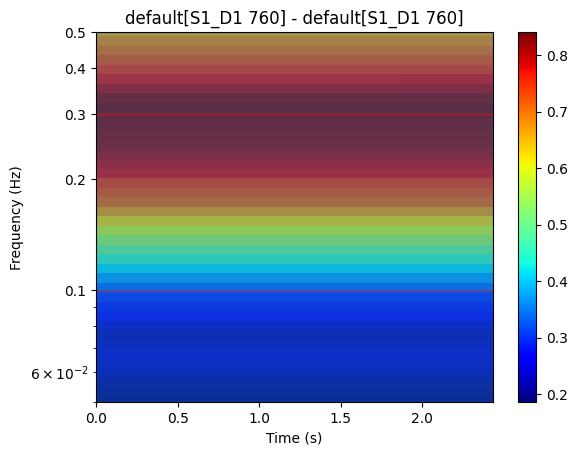

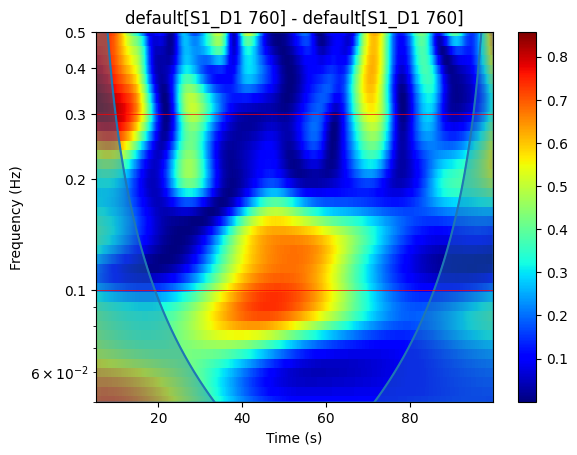

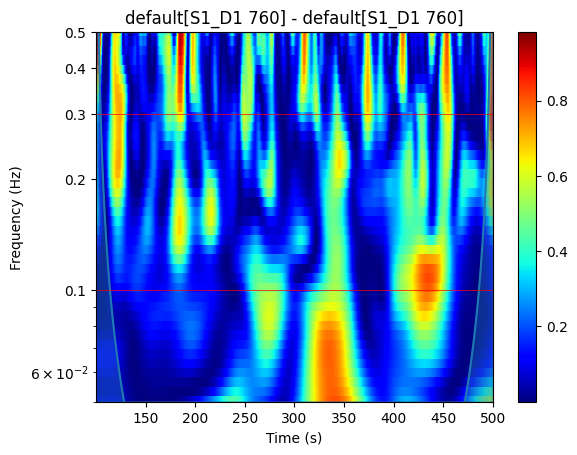

In [12]:

snirf_file1 = '../data/NIRS/DCARE_02_sub1.snirf'
snirf_file2 = '../data/NIRS/DCARE_02_sub2.snirf'
tasks = [
    Task('task1', onset_time=0, duration=500),
]
# Use the same file for the 2 subjects
s1 = FNIRSRecording(tasks=tasks).load_file(snirf_file1)
s2 = FNIRSRecording(tasks=tasks).load_file(snirf_file2)
dyad = FNIRSDyad(s1, s2)

epochs = s1.get_epochs_for_task('task1')
data = epochs.get_data()
# Set some values to NaN to split in 3 sections
data[0, 0, 20:40] = np.nan
t = int(100*epochs.info['sfreq'])
data[0, 0, t:t+1] = np.nan
epochs._data = data
dyad.compute_wtcs(ch_match=epochs.ch_names[0], frequency_cuts=[0.3, 0.1, 0.05], downsample=None)
df = dyad.df

_ = dyad.wtcs[0].plot()
_ = dyad.wtcs[1].plot()
_ = dyad.wtcs[2].plot()

/home/pfortin/work/ppsp/HyPyP-oo/hypyp/wavelet/wtc.py:294: RuntimeWarning: Mean of empty slice
  mat[range_idx, :] = np.nanmean(wtc_range, axis=0)


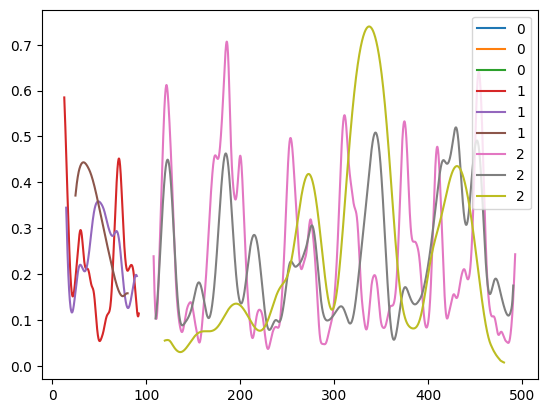

In [13]:
#time_series = [wtc.get_as_time_series(window_size_seconds=1) for wtc in dyad.wtcs]

# plot individually the time series for each WTC, at the right "times" to make sure they are aligned
for wtc in dyad.wtcs:
    x = wtc.times
    for y in wtc.get_as_time_series(window_size_seconds=10):
        plt.plot(x, y, label=wtc.section_id)

plt.legend()
plt.show()


In [14]:
# use the same recording to have perfect coherence,
# but load it twice, otherwise if it is the same python object, it will be computed as "intra-subject"
# use twice the same recording
#dyad = FNIRSDyad(s1, s2)
## use only one channel
#dyad.compute_wtcs(period_cuts=[3, 4, 10], ch_match=['S1_D1 850'])

mat = dyad.get_all_wtcs_as_ts_matrix(dyad.wtcs)
print(mat.shape)
#assert mat.shape[0] == len(dyad.wtcs)
#dyad.wtcs[0].plot()

synchronies = dyad.get_synchrony_time_series()
print(np.nanmean(synchronies.by_task['task1'].time_series_per_range[0]))


(3, 3, 3908)
(3, 3, 3908)
0.2395597779402748


/home/pfortin/work/ppsp/HyPyP-oo/hypyp/fnirs/fnirs_dyad.py:426: RuntimeWarning: Mean of empty slice
  time_series_per_range = np.nanmean(mat, axis=0)


(3, 3, 3908)


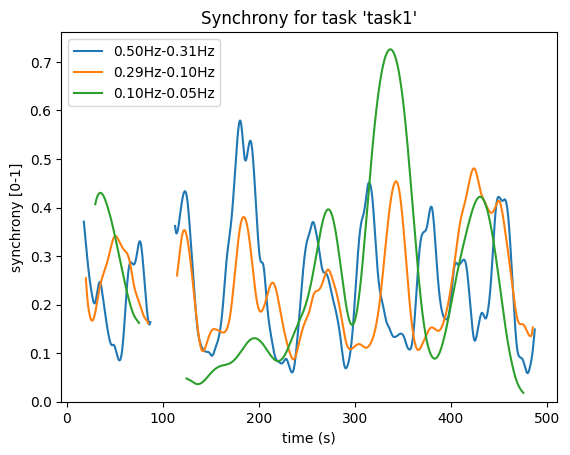

In [15]:

dyad.plot_synchrony_time_series(window_size_seconds=20)
